In [97]:
def correct_cum_from_tifs(cumhdfile, tifdir = 'GEOC.EPOCHS', ext='geo.iono.code.tif', tif_scale2mm = 1, outputhdf = None, directcorrect = True):
    ''' This will load the cum.h5 and either correct cum layer (if directcorrect==True) or add new data var to the cube (if not directcorrect)

    Args:
        cumhdfile (str): input cum.h5 file
        tifdir (str): where to find corrections. Must be in epoch subdirs, e.g. tifdir/20240216/20240216.ext
        ext (str):    what extension is used for the correction files after the epochdate, e.g. 'geo.iono.code.tif', 'tide.geo.tif'
        tif_scale2mm (float):  for iono [rad]: 55.465/(4*np.pi), for SET [m]: 1000, for sltd [rad] same as iono but opposite sign (real delay)
        outputhdf (str):   if None, will overwrite the input file, otherwise will export to this filename (functional: H5, NC, possibly: zarr)
        directcorrect (bool): if True, it will directly reduce the cum data, otherwise it stores it to the datacube
    
    Returns:
        bool:  True if all went ok
    '''
    if not outputhdf:
        outputhdf = cumhdfile
    print('loading LiCSBAS datacube')
    cumxr = load_licsbas_cumh5_as_xrda(cumhdfile)
    print('loading external corrections')
    cumxr = cumcube_remove_from_tifs(cumxr, tifdir, ext, tif_scale2mm, only_load_ext = not directcorrect)
    if type(cumxr) == type(False):
        print('ERROR - probably the correction did not exist for some epochs. Cancelling')
        return False
    cumh = xr.load_dataset(cumhdfile)
    if directcorrect:
        cumh.cum.values = cumh.cum.values - cumxr.values
    else:
        newcumname = 'external_data'
        codes = ['iono', 'tide', 'icams']
        for c in codes:
            if ext.find(c)>-1:
                newcumname = c
        if newcumname in cumh:
            # rename to extension
            newcumname = ext
        if newcumname in cumh:
            print('WARNING, the layer "'+newcumname+'"already existed in the datacube! Will overwrite it now')
        print('storing as variable: '+newcumname)
        cumh[newcumname]=cumh.cum.copy()
        cumh[newcumname].values=cumxr.values
    print('saving to: '+outputhdf)
    cumh.to_netcdf(outputhdf)
    return True


In [ ]:
if [ $setides -gt 0 ]; then
    #echo "insert code to post-correct SET here"
    echo "Note: SET corrections will be applied to cum_filt only"
    echo "python3 -c \"from lics_tstools import *; correct_cum_from_tifs('"$tsdir"/cum_filt.h5', 'GEOC.EPOCHS', 'tide.geo.tif', 1000)\"" >> jasmin_run.sh
    lbreproc=1
    lbreprocname=$lbreprocname'.noSET'
    #correct_cum_from_tifs(cumhdfile, tifdir = 'GEOC.EPOCHS', ext='geo.iono.code.tif', tif_scale2mm = 1, outputhdf = None, directcorrect = True)
  fi
  if [ $iono -gt 0 ]; then
    #echo "insert code to post-correct iono here"
    echo "Note: iono corrections will be applied to cum_filt only"
    echo "python3 -c \"from lics_tstools import *; correct_cum_from_tifs('"$tsdir"/cum_filt.h5', 'GEOC.EPOCHS', 'geo.iono.code.tif', 55.465/(4*np.pi))\"" >> jasmin_run.sh
    lbreproc=1
    lbreprocname=$lbreprocname'.noiono'
  fi
  if [ $lbreproc -gt 0 ]; then
    echo "LiCSBAS_cum2vel.py -i "$tsdir"/cum_filt.h5 -o "$tsdir"/results/vel.filt"$lbreprocname".mskd --vstd --png --mask "$tsdir"/results/mask" >> jasmin_run.sh
    echo "LiCSBAS_flt2geotiff.py -i TS_"$geocd"/results/vel.filt"$lbreprocname".mskd -p "$geocd"/EQA.dem_par -o "$frame".vel_filt"$lbreprocname".mskd.geo.tif" >> jasmin_run.sh
  fi
 fi
 
 if [ $storeext2cube -gt 0 ]; then
  #include generation of outputs
  if [ $setides -gt 0 ]; then
    echo "Additionally, the corrections will be stored in cum.h5 as layer tide"
    echo "python3 -c \"from lics_tstools import *; correct_cum_from_tifs('"$tsdir"/cum.h5', 'GEOC.EPOCHS', 'tide.geo.tif', 1000, directcorrect = False)\"" >> jasmin_run.sh
  fi
  if [ $iono -gt 0 ]; then
    echo "Additionally, the corrections will be stored in cum.h5 as layer iono"
    echo "python3 -c \"from lics_tstools import *; correct_cum_from_tifs('"$tsdir"/cum.h5', 'GEOC.EPOCHS', 'geo.iono.code.tif', 55.465/(4*np.pi), directcorrect = False)\"" >> jasmin_run.sh
  fi
  if [ $gacos -gt 0 ]; then
    echo "Additionally, the corrections will be stored in cum.h5 as layer gacos"
    echo "python3 -c \"from lics_tstools import *; correct_cum_from_tifs('"$tsdir"/cum.h5', 'GACOS', 'sltd.geo.tif', -55.465/(4*np.pi), directcorrect = False)\"" >> jasmin_run.sh
  fi
  if [ $icams -gt 0 ]; then
    echo "Additionally, the corrections will be stored in cum.h5 as layer icams"
    echo "python3 -c \"from lics_tstools import *; correct_cum_from_tifs('"$tsdir"/cum.h5', 'GEOC.EPOCHS', 'icams.sltd.geo.tif', -55.465/(4*np.pi), directcorrect = False)\"" >> jasmin_run.sh
  fi
 fi

In [1]:
import xarray as xr
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import os
from lics_unwrap import *
import re, os, glob
cumfile='/work/scratch-pw2/licsar/mnergiz/remove_me/nosetnoiono/021D_05266_252525/TS_GEOCml10/cum.h5'
cum=xr.open_dataset(cumfile)
sizex = len(cum.vel[0])
sizey = len(cum.vel)
#
lon = cum.corner_lon.values + cum.post_lon.values * np.arange(sizex) - 0.5 * float(cum.post_lon)
lat = cum.corner_lat.values + cum.post_lat.values * np.arange(sizey) + 0.5 * float(cum.post_lat)  # maybe needed? yes! for gridline/AREA that is default in rasterio...
#
time = np.array(([dt.datetime.strptime(str(imd), '%Y%m%d') for imd in cum.imdates.values]))
#
velxr = xr.DataArray(cum.vel.values.reshape(sizey, sizex), coords=[lat, lon], dims=["lat", "lon"])
# LiCSBAS uses 0 instead of nans...
velxr = velxr.where(velxr != 0)
velxr.attrs['unit'] = 'mm/year'
# vinterceptxr = xr.DataArray(cum.vintercept.values.reshape(sizey,sizex), coords=[lat, lon], dims=["lat", "lon"])
#
cumxr = xr.DataArray(cum.cum.values, coords=[time, lat, lon], dims=["time", "lat", "lon"])
cumxr.attrs['unit'] = 'mm'
refarea = str(cum.refarea.values)
# x is first...
refx1 = int(refarea.split('/')[0].split(':')[0])
refx2 = int(refarea.split('/')[0].split(':')[1])
refy1 = int(refarea.split('/')[1].split(':')[0])
refy2 = int(refarea.split('/')[1].split(':')[1])
refx=int((refx2+refx1)/2)
refy = int((refy2 + refy1) / 2)
cumxr.attrs['ref_lon'] = cumxr.lon.values[refx]
cumxr.attrs['ref_lat'] = cumxr.lat.values[refy]



setting pyproj data directory


In [4]:
cumxr

<xarray.DataArray (time: 71, lat: 469, lon: 386)>
array([[[ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        ..., 
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]],

       [[ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        ..., 
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]],

       [[ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        ..., 
...
        ..., 
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]],

       [[ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        ..., 
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]],

       [[ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        ..., 
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]]], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 2019-06-01 2019-06-07 ... 2020-07-31
  * lat      (lat) float64 39.64 39.63 39.62 39.61 ... 34.99 34.98 34.97 34.96
  * lon      (lon) float64 35.32 35.33 35.34 35.35 ... 39.14 39.15 39.16 39.17
Attributes:
    unit:     mm
    ref_lon:  37.665
    ref_lat:  35.6716666

In [11]:
# def cumcube_remove_from_tifs(cumxr, tifdir = 'GEOC.EPOCHS', ext='geo.iono.code.tif', tif_scale2mm = 1, only_load_ext = False):
# ''' Correct directly from tifs, no need to store in cubes.
# NOTE - you can also just load the exts into the cumcube without removing anything..
# (in any case, values are referred temporally to the first epoch)

# Args:
#     cumxr (xr.DataArray): only cum
#     tifdir:
#     ext:
#     tif_scale2mm:  for iono [rad]: (0.055465*1000)/(4*np.pi), for SET [m]: 1/1000
#     only_load_ext:  would only load the ext files in the cube and return it (no removal!)
    
# Returns:
#     xr.DataArray: corrected cum values (only_load_ext=False) or only loaded corrections
# '''
#if check_complete_set(cumxr.time.values)
#times = cumxr.time.values
reflon, reflat = cumxr.attrs['ref_lon'], cumxr.attrs['ref_lat']
#
firstepvals = 0
leneps = len(cumxr)
tifdir='/work/scratch-pw2/licsar/mnergiz/remove_me/nosetnoiono/021D_05266_252525/GEOC.EPOCHS'
ext='tide.geo.azi.tif'
tif_scale2mm=(0.055465*1000)/(4*np.pi)
for i in range(leneps): # times first coord..
    print('  Running for {0:6}/{1:6}th epoch'.format(i+1, leneps), flush=True, end='\r')
    cumepoch = cumxr[i]
    epoch = str(cumepoch.time.values).split('T')[0].replace('-','') 
    extif = os.path.join(tifdir, epoch, epoch+'.'+ext)
    if not os.path.exists(extif):
        extif = os.path.join(tifdir, epoch + '.' + ext)
    if not os.path.exists(extif):
        print('\n\r WARNING: no correction available for epoch '+epoch+'. Filling with NaNs')
        extepoch = cumepoch.copy() * np.nan
        extepoch.attrs.clear()
    else:
        extepoch = load_tif2xr(extif)
        extepoch = extepoch.where(extepoch != 0) # just in case...
        extepoch = extepoch * tif_scale2mm
        extepoch = extepoch.interp_like(cumepoch, method='linear') # CHECK!
        extepoch = extepoch - extepoch.sel(lon=reflon, lat=reflat, method='nearest') # could be done better though
    # if i == 0:
#         firstepvals = extepoch.fillna(0).values
#     # here we do diff w.r.t. first epoch
#     extepoch.values = extepoch.values - firstepvals
#     # mask that - not needed (?)
#     #extepoch = extepoch.where(~np.isnan(cumxr[i]))
#     if only_load_ext:
#         cumxr.values[i] = extepoch.values
#     else:
#         cumxr.values[i] = cumxr.values[i] - extepoch.values
# print('\n\r  done')
# #if only_load_ext:
# #    cumxr = cumxr-cumxr[0] #.cumsum(axis=0)
# #    cumxr = cumxr.cumsum(axis=0)-cumxr[0]
# return cumxr    ''' Correct directly from tifs, no need to store in cubes.
    # NOTE - you can also just load the exts into the cumcube without removing anything..
    # (in any case, values are referred temporally to the first epoch)
    
    # Args:
    #     cumxr (xr.DataArray): only cum
    #     tifdir:
    #     ext:
    #     tif_scale2mm:  for iono [rad]: (0.055465*1000)/(4*np.pi), for SET [m]: 1/1000
    #     only_load_ext:  would only load the ext files in the cube and return it (no removal!)
        
    # Returns:
    #     xr.DataArray: corrected cum values (only_load_ext=False) or only loaded corrections
    # '''
    # #if check_complete_set(cumxr.time.values)
    # #times = cumxr.time.values

In [86]:
# def cumcube_sbovl_remove_from_tifs(cumxr, tifdir = 'GEOC.EPOCHS', ext='geo.iono.code.sTECA.tif', tif_scale2mm = 1000, only_load_ext = False):
#     ''' Correct directly from tifs, no need to store in cubes.
#     NOTE - you can also just load the exts into the cumcube without removing anything..
#     (in any case, values are referred temporally to the first epoch)
    
#     Args:
#         cumxr (xr.DataArray): only cum
#         tifdir:
#         ext1: sTECA
#         ext2: sTECB
#         tif_scale2mm:  for iono [rad]: 1000 for sTECA/B
#         only_load_ext:  would only load the ext files in the cube and return it (no removal!)
        
#     Returns:
#         xr.DataArray: corrected cum values (only_load_ext=False) or only loaded corrections
#     '''
#     #if check_complete_set(cumxr.time.values)
#     #times = cumxr.time.values
#     reflon, reflat = cumxr.attrs['ref_lon'], cumxr.attrs['ref_lat']
#     #
from scipy.constants import speed_of_light
tifdir='/work/scratch-pw2/licsar/mnergiz/remove_me/nosetnoiono/021D_05266_252525/GEOC.EPOCHS'
ext='geo.iono.code.sTECA.tif'
firstepvals = 0
leneps = len(cumxr)
cumxr_corrrection=xr.zeros_like(cumxr)
cumxr_removed=xr.zeros_like(cumxr)
for i in range(leneps): # times first coord..
    print('  Running for {0:6}/{1:6}th epoch'.format(i+1, leneps), flush=True, end='\r')
    cumepoch = cumxr[i]
    epoch = str(cumepoch.time.values).split('T')[0].replace('-','')
    if 'STEC' in ext.upper():
        ext1='geo.iono.code.sTECA.tif'
        ext2='geo.iono.code.sTECB.tif'
    extif1 = os.path.join(tifdir, epoch, epoch+'.'+ext1)
    extif2 = os.path.join(tifdir, epoch, epoch+'.'+ext2)
    if not os.path.exists(extif) or not os.path.exists(extif2):
        extif1 = os.path.join(tifdir, epoch + '.' + ext1)
        extif2 = os.path.join(tifdir, epoch + '.' + ext2)
    if not os.path.exists(extif1) or not os.path.exists(extif2):
        print('\n\r WARNING: no correction available for epoch '+epoch+'. Filling with NaNs')
        ##backward
        extepoch1 = cumepoch.copy() * np.nan
        extepoch1.attrs.clear()
        #forward
        extepoch2 = cumepoch.copy() * np.nan
        extepoch2.attrs.clear()
    else:
        #backward
        extepoch1 = load_tif2xr(extif1)
        extepoch1 = extepoch1.where(extepoch1 != 0) # just in case...
        # extepoch1 = extepoch1.interp_like(cumepoch, method='linear') # CHECK!
        #forward
        extepoch2 = load_tif2xr(extif2)
        extepoch2 = extepoch2.where(extepoch2 != 0)
        # extepoch2 = extepoch2.interp_like(cumepoch, method='linear')
        

    # extepoch2 = extepoch2 - extepoch2.sel(lon=reflon, lat=reflat, method='nearest')
    ####gradient method Lazecky et al. 2023,GRL #https://github.com/comet-licsar/daz/blob/main/lib/daz_iono.py#L561
    ###parameter for TEC gradient
    azpix=14000
    PRF = 486.486
    k = 40.308193 # m^3 / s^2
    f0 = 5.4050005e9
    c = speed_of_light
    
    ##scaling_tif
    workdir=os.getcwd()
    frame='021D_05266_252525'
    metafolder = os.path.join(os.environ['LiCSAR_public'], str(int(frame[:3])), frame, 'metadata')
    # Check if the metadata folder exists
    if os.path.exists(metafolder) and os.path.isdir(metafolder):
        scaling_tif = None  # Initialize variable to track if a file is found
        
        for files in os.listdir(metafolder):  
            if files.endswith('.geo.sbovl_scaling.tif'):
                scaling_tif = os.path.join(metafolder, files)
        # Check if no scaling file was found
        if scaling_tif is None:
            print("No .geo.sbovl_scaling.tif file found in metadata folder.")
    else:
        print(f"metadata is not exist in LiCSAR_public")  

    ##scaling2dfdc
    scaling_factor=load_tif2xr(scaling_tif)
    dfDC=azpix*PRF/(2*np.pi*scaling_factor)
    fH = f0 + dfDC*0.5
    fL = f0 - dfDC*0.5
    tecovl=(extepoch1/fH-extepoch2/fL)
    iono_grad = 2*PRF*k/c/dfDC * tecovl #unitless
    iono_grad_mm=iono_grad*azpix #mm
    
    ##TODO check this useful for sbovl or not?
    iono_grad_mm = iono_grad_mm - iono_grad_mm.sel(lon=reflon, lat=reflat, method='nearest') # could be done better though
    if i == 0:
        firstepvals = iono_grad_mm.fillna(0).values
    # here we do diff w.r.t. first epoch
    iono_grad_mm.values = iono_grad_mm.values - firstepvals
    iono_grad_mm_int = iono_grad_mm.interp_like(cumxr, method='linear')
    cumxr_corrrection.values[i] = iono_grad_mm.values
    cumxr_removed.values[i] = cumxr.values[i] - iono_grad_mm.values
    sys.exit()
print('\n\r  done')
sys.exit()
        

ValueError: could not broadcast input array from shape (4694,3867) into shape (469,386)

In [87]:
iono_grad_mm

<xarray.DataArray (lat: 4694, lon: 3867)>
array([[ nan,  nan,  nan, ...,  nan,  nan,  nan],
       [ nan,  nan,  nan, ...,  nan,  nan,  nan],
       [ nan,  nan,  nan, ...,  nan,  nan,  nan],
       ..., 
       [ nan,  nan,  nan, ...,  nan,  nan,  nan],
       [ nan,  nan,  nan, ...,  nan,  nan,  nan],
       [ nan,  nan,  nan, ...,  nan,  nan,  nan]], dtype=float32)
Coordinates:
  * lon          (lon) float64 35.33 35.33 35.33 35.33 ... 39.19 39.19 39.2
  * lat          (lat) float64 39.65 39.65 39.64 39.64 ... 34.96 34.95 34.95
    spatial_ref  int64 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0

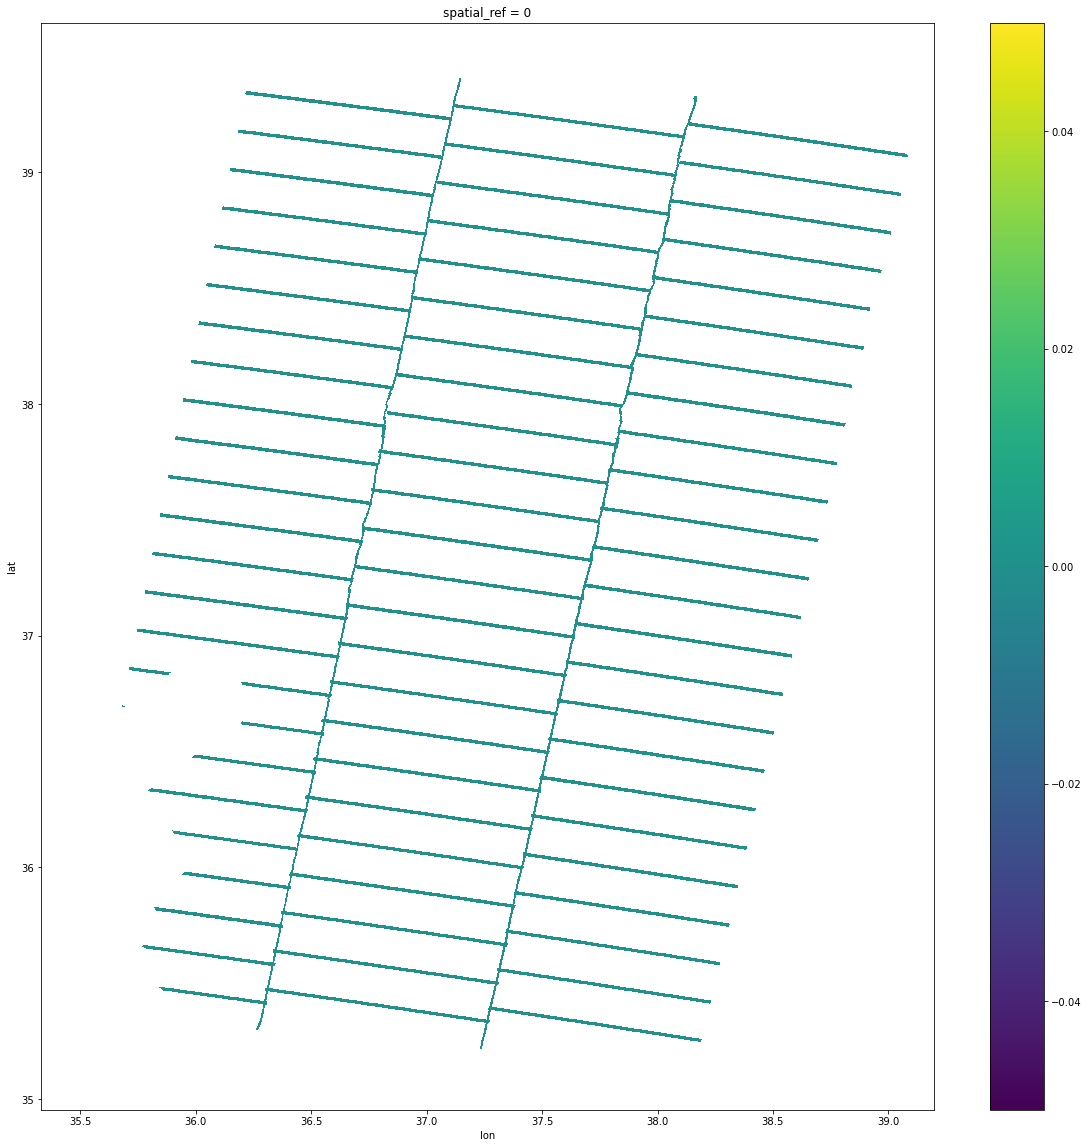

In [94]:
iono_grad_mm.plot(figsize=(20,20))

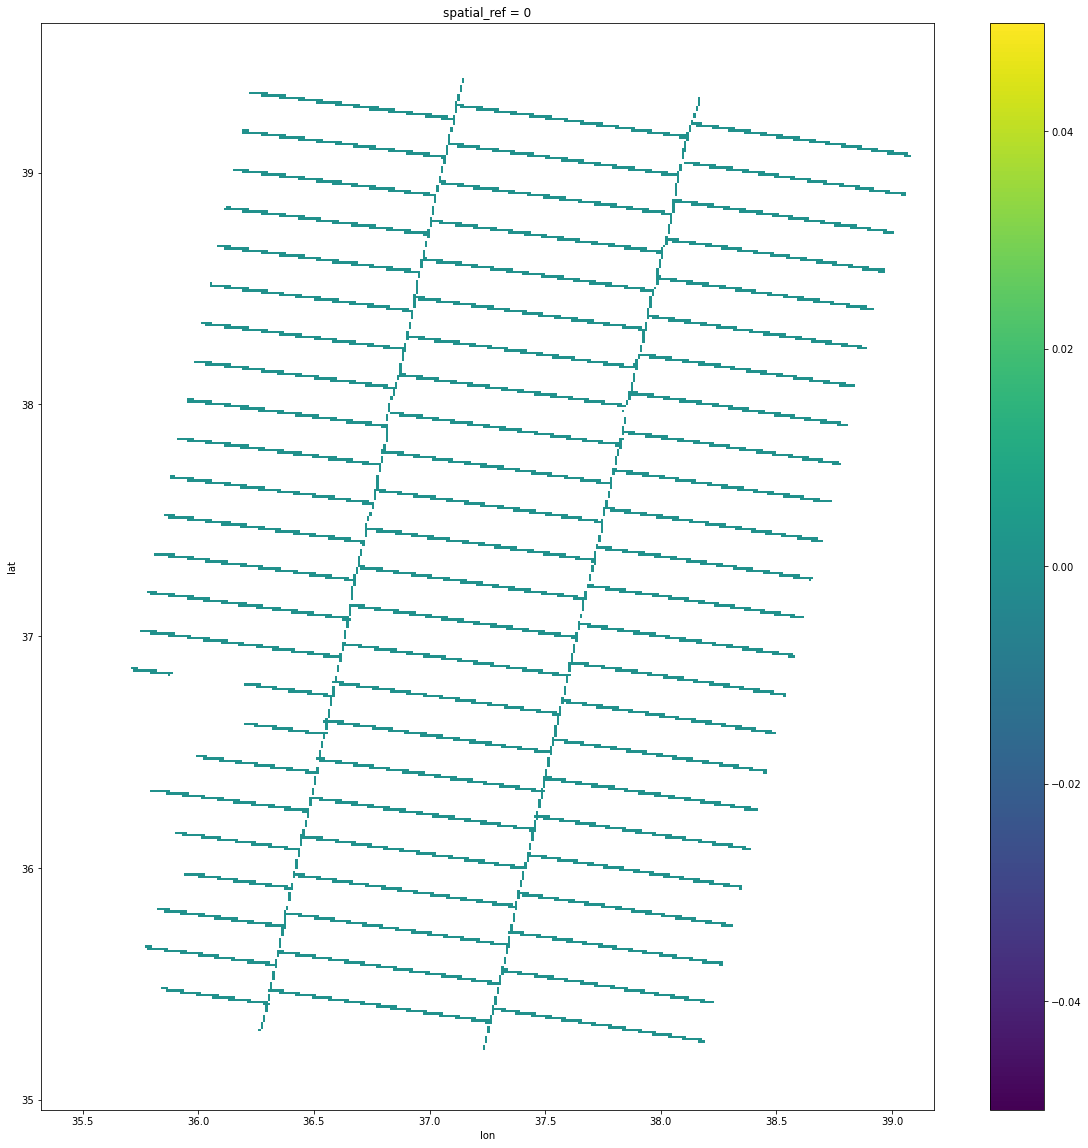

In [93]:
iono_grad_mm_int.plot(figsize=(20,20))

In [55]:
extepoch2int = extepoch2.interp_like(cumepoch, method='linear')

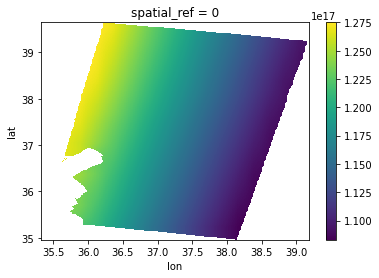

In [56]:
extepoch2int.plot()

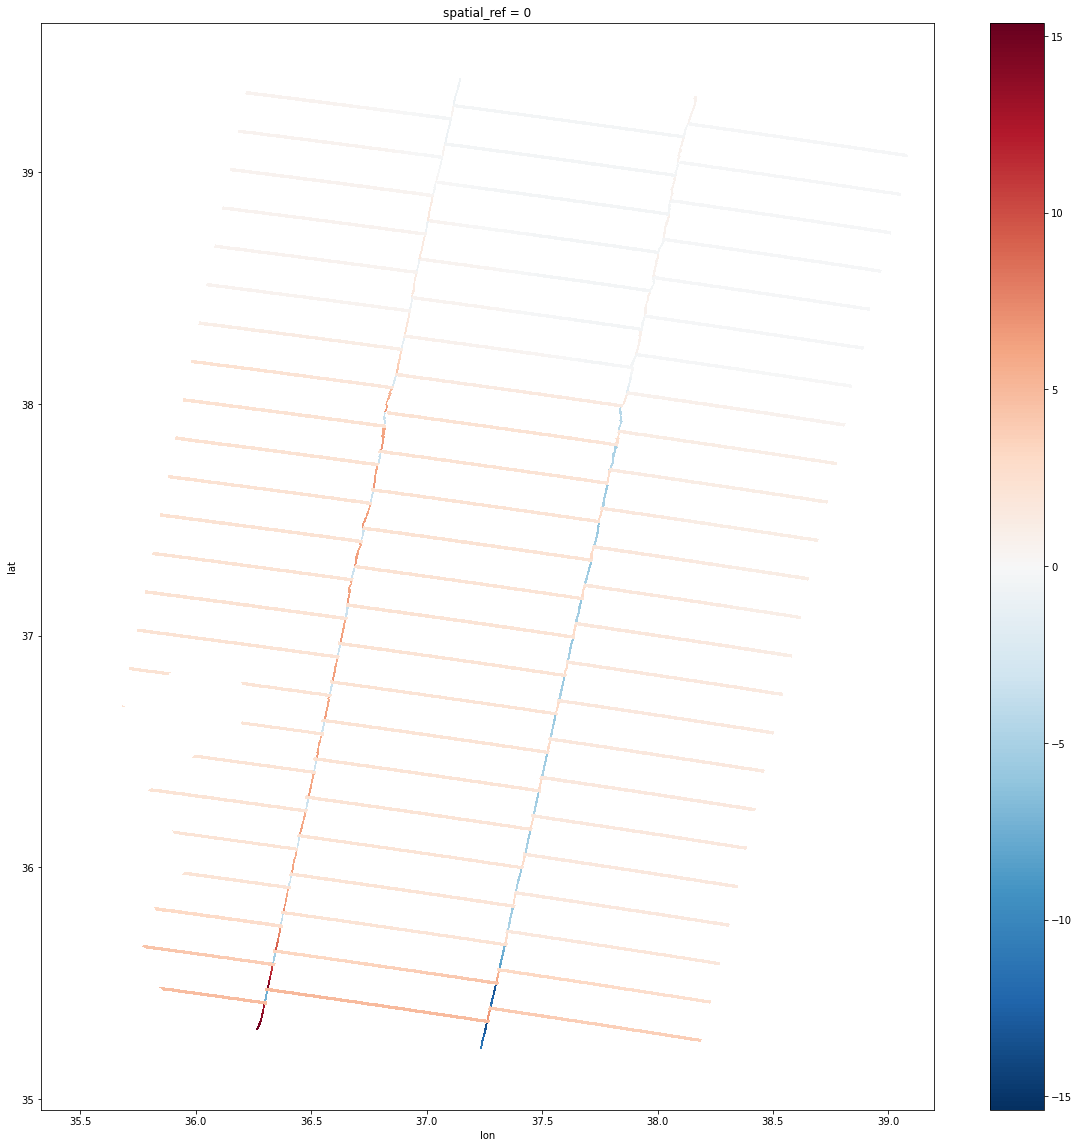

In [62]:
iono_grad_mm.plot(figsize=(20,20))

In [71]:
# extepoch = extepoch.where(extepoch != 0) # just in case...
# extepoch = extepoch * 1000
extepoch = extepoch.interp_like(cumepoch, method='linear') # CHECK!

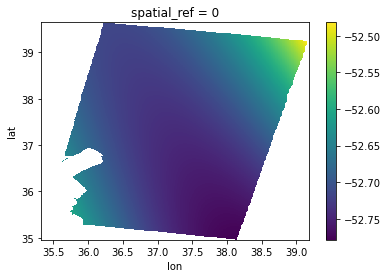

In [72]:
extepoch.plot()

In [ ]:
def cumcube_remove_from_tifs(cumxr, tifdir = 'GEOC.EPOCHS', ext='geo.iono.code.tif', tif_scale2mm = 1, only_load_ext = False):
    ''' Correct directly from tifs, no need to store in cubes.
    NOTE - you can also just load the exts into the cumcube without removing anything..
    (in any case, values are referred temporally to the first epoch)
    
    Args:
        cumxr (xr.DataArray): only cum
        tifdir:
        ext:
        tif_scale2mm:  for iono [rad]: (0.055465*1000)/(4*np.pi), for SET [m]: 1/1000
        only_load_ext:  would only load the ext files in the cube and return it (no removal!)
        
    Returns:
        xr.DataArray: corrected cum values (only_load_ext=False) or only loaded corrections
    '''
    #if check_complete_set(cumxr.time.values)
    #times = cumxr.time.values
    reflon, reflat = cumxr.attrs['ref_lon'], cumxr.attrs['ref_lat']
    #
    firstepvals = 0
    leneps = len(cumxr)
    for i in range(leneps): # times first coord..
        print('  Running for {0:6}/{1:6}th epoch'.format(i+1, leneps), flush=True, end='\r')
        cumepoch = cumxr[i]
        epoch = str(cumepoch.time.values).split('T')[0].replace('-','')
        extif = os.path.join(tifdir, epoch, epoch+'.'+ext)
        if not os.path.exists(extif):
            extif = os.path.join(tifdir, epoch + '.' + ext)
        if not os.path.exists(extif):
            print('\n\r WARNING: no correction available for epoch '+epoch+'. Filling with NaNs')
            extepoch = cumepoch.copy() * np.nan
            extepoch.attrs.clear()
        else:
            extepoch = load_tif2xr(extif)
            extepoch = extepoch.where(extepoch != 0) # just in case...
            extepoch = extepoch * tif_scale2mm
            extepoch = extepoch.interp_like(cumepoch, method='linear') # CHECK!
            extepoch = extepoch - extepoch.sel(lon=reflon, lat=reflat, method='nearest') # could be done better though
        if i == 0:
            firstepvals = extepoch.fillna(0).values
        # here we do diff w.r.t. first epoch
        extepoch.values = extepoch.values - firstepvals
        # mask that - not needed (?)
        #extepoch = extepoch.where(~np.isnan(cumxr[i]))
        if only_load_ext:
            cumxr.values[i] = extepoch.values
        else:
            cumxr.values[i] = cumxr.values[i] - extepoch.values
    print('\n\r  done')
    #if only_load_ext:
    #    cumxr = cumxr-cumxr[0] #.cumsum(axis=0)
    #    cumxr = cumxr.cumsum(axis=0)-cumxr[0]
    return cumxr

In [95]:
cumfile='/work/scratch-pw2/licsar/mnergiz/nosetnoiono/116A_05207_252525/TS_GEOCml10/cum_filt.h5'

In [98]:
def load_licsbas_cumh5_as_xrda(cumfile):
    ''' Loads cum.h5 (now only cum layer) as standard xr.DataArray (in lon/lat)'''
    cum = xr.load_dataset(cumfile)
    #
    sizex = len(cum.vel[0])
    sizey = len(cum.vel)
    #
    lon = cum.corner_lon.values + cum.post_lon.values * np.arange(sizex) - 0.5 * float(cum.post_lon)
    lat = cum.corner_lat.values + cum.post_lat.values * np.arange(sizey) + 0.5 * float(cum.post_lat)  # maybe needed? yes! for gridline/AREA that is default in rasterio...
    #
    time = np.array(([dt.datetime.strptime(str(imd), '%Y%m%d') for imd in cum.imdates.values]))
    #
    velxr = xr.DataArray(cum.vel.values.reshape(sizey, sizex), coords=[lat, lon], dims=["lat", "lon"])
    # LiCSBAS uses 0 instead of nans...
    velxr = velxr.where(velxr != 0)
    velxr.attrs['unit'] = 'mm/year'
    # vinterceptxr = xr.DataArray(cum.vintercept.values.reshape(sizey,sizex), coords=[lat, lon], dims=["lat", "lon"])
    #
    cumxr = xr.DataArray(cum.cum.values, coords=[time, lat, lon], dims=["time", "lat", "lon"])
    cumxr.attrs['unit'] = 'mm'
    refarea = str(cum.refarea.values)
    # x is first...
    refx1 = int(refarea.split('/')[0].split(':')[0])
    refx2 = int(refarea.split('/')[0].split(':')[1])
    refy1 = int(refarea.split('/')[1].split(':')[0])
    refy2 = int(refarea.split('/')[1].split(':')[1])
    refx=int((refx2+refx1)/2)
    refy = int((refy2 + refy1) / 2)
    cumxr.attrs['ref_lon'] = cumxr.lon.values[refx]
    cumxr.attrs['ref_lat'] = cumxr.lat.values[refy]
    return cumxr

In [101]:
cumnc='/work/scratch-pw2/licsar/mnergiz/nosetnoiono/116A_05207_252525/TScum_filt.nc'

In [102]:
ds = xr.open_dataset(cumnc)

In [103]:
ds

<xarray.Dataset>
Dimensions:      (time: 179, lat: 468, lon: 387)
Coordinates:
  * time         (time) datetime64[ns] 2017-06-05 2017-06-11 ... 2020-06-01
  * lat          (lat) float64 35.59 35.6 35.61 35.62 ... 40.24 40.25 40.26
  * lon          (lon) float64 36.05 36.06 36.07 36.08 ... 39.89 39.9 39.91
Data variables:
    cum          (time, lat, lon) float32 ...
    vel          (lat, lon) float32 ...
    coh          (lat, lon) float32 ...
    rms          (lat, lon) float32 ...
    vstd         (lat, lon) float32 ...
    stc          (lat, lon) float32 ...
    vel_filt     (lat, lon) float64 ...
    spatial_ref  int64 ...